# Data Loading and Preprocessing

In [1]:
import zipfile
import os

zip_path = "/content/ECE1508Dataset.zip"
extract_path = "/content/metr_la_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    for f in files:
        print("  ", f)

Folder: /content/metr_la_data
   METR-LA.h5
   adj_METR-LA.pkl


In [2]:
import pandas as pd
import os

h5_path = None
for root, dirs, files in os.walk("/content/metr_la_data"):
    for f in files:
        if f.endswith(".h5"):
            h5_path = os.path.join(root, f)

print("h5_path =", h5_path)

df = pd.read_hdf(h5_path)
print("shape:", df.shape)
display(df.head())

h5_path = /content/metr_la_data/METR-LA.h5
shape: (34272, 207)


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [3]:
print("index type:", type(df.index))
print("first 5 timestamps:", df.index[:5].tolist())
print("first 10 sensor ids:", df.columns[:10].tolist())

index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
first 5 timestamps: [Timestamp('2012-03-01 00:00:00'), Timestamp('2012-03-01 00:05:00'), Timestamp('2012-03-01 00:10:00'), Timestamp('2012-03-01 00:15:00'), Timestamp('2012-03-01 00:20:00')]
first 10 sensor ids: ['773869', '767541', '767542', '717447', '717446', '717445', '773062', '767620', '737529', '717816']


In [4]:
import numpy as np

data = df.values

print("data shape:", data.shape)
print(data[:3, :5])

data shape: (34272, 207)
[[64.375      67.625      67.125      61.5        66.875     ]
 [62.66666667 68.55555556 65.44444444 62.44444444 64.44444444]
 [64.         63.75       60.         59.         66.5       ]]


In [5]:
data = np.expand_dims(data, axis=-1)

print("new shape:", data.shape)

new shape: (34272, 207, 1)


In [6]:
def create_sequences(data, input_len=12, pred_len=1):
    X = []
    y = []

    T = data.shape[0]

    for i in range(T - input_len - pred_len + 1):
        X.append(data[i:i + input_len])
        y.append(data[i + input_len:i + input_len + pred_len])

    return np.array(X), np.array(y)

X, y = create_sequences(data, 12, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (34260, 12, 207, 1)
y shape: (34260, 1, 207, 1)


In [7]:
num_samples = X.shape[0]

train_size = int(num_samples * 0.7)
val_size = int(num_samples * 0.1)
test_size = num_samples - train_size - val_size

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("train:", X_train.shape)
print("val:", X_val.shape)
print("test:", X_test.shape)

train: (23982, 12, 207, 1)
val: (3426, 12, 207, 1)
test: (6852, 12, 207, 1)


In [8]:
print("Before reshape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Before reshape:
X_train: (23982, 12, 207, 1)
y_train: (23982, 1, 207, 1)
X_val: (3426, 12, 207, 1)
y_val: (3426, 1, 207, 1)
X_test: (6852, 12, 207, 1)
y_test: (6852, 1, 207, 1)


# Baseline LSTM

In [9]:
X_train_lstm = X_train.squeeze(-1)
X_val_lstm = X_val.squeeze(-1)
X_test_lstm = X_test.squeeze(-1)

y_train_lstm = y_train.squeeze(1).squeeze(-1)
y_val_lstm = y_val.squeeze(1).squeeze(-1)
y_test_lstm = y_test.squeeze(1).squeeze(-1)

print("After reshape:")
print("X_train_lstm:", X_train_lstm.shape)
print("y_train_lstm:", y_train_lstm.shape)
print("X_val_lstm:", X_val_lstm.shape)
print("y_val_lstm:", y_val_lstm.shape)
print("X_test_lstm:", X_test_lstm.shape)
print("y_test_lstm:", y_test_lstm.shape)

After reshape:
X_train_lstm: (23982, 12, 207)
y_train_lstm: (23982, 207)
X_val_lstm: (3426, 12, 207)
y_val_lstm: (3426, 207)
X_test_lstm: (6852, 12, 207)
y_test_lstm: (6852, 207)


In [10]:
train_mean = X_train_lstm.mean()
train_std = X_train_lstm.std()

X_train_lstm = (X_train_lstm - train_mean) / (train_std + 1e-8)
X_val_lstm = (X_val_lstm - train_mean) / (train_std + 1e-8)
X_test_lstm = (X_test_lstm - train_mean) / (train_std + 1e-8)

y_train_lstm = (y_train_lstm - train_mean) / (train_std + 1e-8)
y_val_lstm = (y_val_lstm - train_mean) / (train_std + 1e-8)
y_test_lstm = (y_test_lstm - train_mean) / (train_std + 1e-8)

print("mean:", train_mean)
print("std:", train_std)

mean: 54.407150982748384
std: 19.492308569036222


In [11]:
import torch
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_lstm, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_lstm, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_lstm, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_lstm, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

device: cpu


In [12]:
import torch.nn as nn

class BaselineLSTM(nn.Module):
    def __init__(self, input_size=207, hidden_size=64, num_layers=2, output_size=207, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_out = out[:, -1, :]
        y_hat = self.fc(last_out)
        return y_hat

In [13]:
model = BaselineLSTM(
    input_size=207,
    hidden_size=64,
    num_layers=2,
    output_size=207,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

BaselineLSTM(
  (lstm): LSTM(207, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=207, bias=True)
)


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [15]:
lstm_train_losses = []
lstm_val_losses = []

num_epochs = 30

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, lstm_optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1/30 | Train Loss: 0.348195 | Val Loss: 0.285972
Epoch 2/30 | Train Loss: 0.220868 | Val Loss: 0.230714
Epoch 3/30 | Train Loss: 0.190604 | Val Loss: 0.208006
Epoch 4/30 | Train Loss: 0.175131 | Val Loss: 0.199808
Epoch 5/30 | Train Loss: 0.167182 | Val Loss: 0.189771
Epoch 6/30 | Train Loss: 0.160820 | Val Loss: 0.187157
Epoch 7/30 | Train Loss: 0.156409 | Val Loss: 0.188514
Epoch 8/30 | Train Loss: 0.152363 | Val Loss: 0.184177
Epoch 9/30 | Train Loss: 0.148036 | Val Loss: 0.184803
Epoch 10/30 | Train Loss: 0.144375 | Val Loss: 0.181312
Epoch 11/30 | Train Loss: 0.140743 | Val Loss: 0.185670
Epoch 12/30 | Train Loss: 0.139360 | Val Loss: 0.187446
Epoch 13/30 | Train Loss: 0.136743 | Val Loss: 0.188698
Epoch 14/30 | Train Loss: 0.134431 | Val Loss: 0.182876
Epoch 15/30 | Train Loss: 0.131076 | Val Loss: 0.189731
Epoch 16/30 | Train Loss: 0.128500 | Val Loss: 0.203122
Epoch 17/30 | Train Loss: 0.125830 | Val Loss: 0.201946
Epoch 18/30 | Train Loss: 0.123968 | Val Loss: 0.208805
E

In [16]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu()

        all_preds.append(preds)
        all_targets.append(y_batch)

all_preds = torch.cat(all_preds, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

print("pred shape:", all_preds.shape)
print("target shape:", all_targets.shape)

pred shape: (6852, 207)
target shape: (6852, 207)


In [17]:
all_preds_denorm = all_preds * (train_std + 1e-8) + train_mean
all_targets_denorm = all_targets * (train_std + 1e-8) + train_mean

In [18]:
import numpy as np

def MAE(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def RMSE(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def MAPE(y_true, y_pred):
    mask = y_true > 10
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [19]:
mae = MAE(all_targets_denorm, all_preds_denorm)
rmse = RMSE(all_targets_denorm, all_preds_denorm)
mape = MAPE(all_targets_denorm, all_preds_denorm)

print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAPE: {mape:.2f}%")

Test MAE: 5.3049
Test RMSE: 10.1621
Test MAPE: 9.72%


# STGCN

In [21]:
import pickle

pkl_path = "/content/metr_la_data/adj_METR-LA.pkl"

with open(pkl_path, "rb") as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding="latin1")

print("adj_mx shape:", adj_mx.shape)
print("num sensors:", len(sensor_ids))
print("adj sample:")
print(adj_mx[:5, :5])

adj_mx shape: (207, 207)
num sensors: 207
adj sample:
[[1.         0.         0.         0.         0.        ]
 [0.         1.         0.3909554  0.         0.        ]
 [0.         0.7174379  1.         0.         0.        ]
 [0.         0.         0.         1.         0.63372165]
 [0.         0.         0.         0.62646437 1.        ]]


In [22]:
A = adj_mx

# add self-loop
A_hat = A + np.eye(A.shape[0])

# degree matrix
D = np.diag(np.sum(A_hat, axis=1))

# D^(-1/2)
D_inv_sqrt = np.linalg.inv(np.sqrt(D))

# normalized adjacency
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

print("A_norm shape:", A_norm.shape)
print(A_norm[:5, :5])

A_norm shape: (207, 207)
[[0.34019118 0.         0.         0.         0.        ]
 [0.         0.41601695 0.07421152 0.         0.        ]
 [0.         0.13618474 0.34644732 0.         0.        ]
 [0.         0.         0.         0.27213984 0.08519316]
 [0.         0.         0.         0.08421754 0.2656319 ]]


In [23]:
A_norm = torch.tensor(A_norm, dtype=torch.float32).to(device)

print(A_norm.shape)

torch.Size([207, 207])


In [24]:
import torch.nn as nn

class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, X, A_norm):
        # X shape: (batch, nodes, features)
        AX = torch.matmul(A_norm, X)
        out = self.linear(AX)
        return out

In [25]:
class TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            (kernel_size,1),
            padding=(kernel_size//2,0)
        )

    def forward(self, X):
        # X: (batch, channels, time, nodes)
        return self.conv(X)

In [26]:
class STGCNBlock(nn.Module):
    def __init__(self, in_channels, spatial_channels, out_channels):
        super().__init__()

        self.temp1 = TemporalConv(in_channels, spatial_channels)
        self.graph_conv = GraphConv(spatial_channels, spatial_channels)
        self.temp2 = TemporalConv(spatial_channels, out_channels)

        self.relu = nn.ReLU()

    def forward(self, X, A_norm):
        # X shape: (batch, channels, time, nodes)

        t = self.temp1(X)
        t = self.relu(t)

        # reshape for graph conv
        B, C, T, N = t.shape
        t = t.permute(0,2,3,1).reshape(B*T, N, C)

        t = self.graph_conv(t, A_norm)

        t = t.reshape(B, T, N, C).permute(0,3,1,2)

        t = self.temp2(t)
        return self.relu(t)

In [27]:
class STGCN(nn.Module):
    def __init__(self, num_nodes=207):
        super().__init__()

        self.block1 = STGCNBlock(1, 32, 32)
        self.block2 = STGCNBlock(32, 32, 32)

        self.final = nn.Conv2d(32, 1, (1,1))

    def forward(self, X, A_norm):
        # X shape: (batch, time, nodes, features)

        X = X.permute(0,3,1,2)

        X = self.block1(X, A_norm)
        X = self.block2(X, A_norm)

        out = self.final(X)

        out = out[:,:, -1,:]

        return out.squeeze(1)

In [28]:
stgcn = STGCN().to(device)

criterion = nn.MSELoss()
stgcn_optimizer = torch.optim.Adam(stgcn.parameters(), lr=1e-3)

print(stgcn)

STGCN(
  (block1): STGCNBlock(
    (temp1): TemporalConv(
      (conv): Conv2d(1, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (graph_conv): GraphConv(
      (linear): Linear(in_features=32, out_features=32, bias=True)
    )
    (temp2): TemporalConv(
      (conv): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (relu): ReLU()
  )
  (block2): STGCNBlock(
    (temp1): TemporalConv(
      (conv): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (graph_conv): GraphConv(
      (linear): Linear(in_features=32, out_features=32, bias=True)
    )
    (temp2): TemporalConv(
      (conv): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (relu): ReLU()
  )
  (final): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [29]:
X_train_st = X_train_lstm[..., np.newaxis]
X_val_st = X_val_lstm[..., np.newaxis]
X_test_st = X_test_lstm[..., np.newaxis]

y_train_st = y_train_lstm
y_val_st = y_val_lstm
y_test_st = y_test_lstm

print("X_train:", X_train_st.shape)
print("y_train:", y_train_st.shape)
print("mean check:", X_train_st.mean())

X_train: (23982, 12, 207, 1)
y_train: (23982, 207)
mean check: -8.295474947913112e-15


In [30]:
X_train_st_tensor = torch.tensor(X_train_st, dtype=torch.float32)
y_train_st_tensor = torch.tensor(y_train_st, dtype=torch.float32)

X_val_st_tensor = torch.tensor(X_val_st, dtype=torch.float32)
y_val_st_tensor = torch.tensor(y_val_st, dtype=torch.float32)

X_test_st_tensor = torch.tensor(X_test_st, dtype=torch.float32)
y_test_st_tensor = torch.tensor(y_test_st, dtype=torch.float32)

print(X_train_st_tensor.shape)
print(y_train_st_tensor.shape)

torch.Size([23982, 12, 207, 1])
torch.Size([23982, 207])


In [31]:
train_dataset = TensorDataset(X_train_st_tensor, y_train_st_tensor)
val_dataset = TensorDataset(X_val_st_tensor, y_val_st_tensor)
test_dataset = TensorDataset(X_test_st_tensor, y_test_st_tensor)

train_loader_st = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_st = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_st = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [32]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch, A_norm)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [33]:
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch, A_norm)
            loss = criterion(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [34]:
stgcn_train_losses = []
stgcn_val_losses = []

epochs = 30

for epoch in range(epochs):
    train_loss = train_epoch(stgcn, train_loader_st, stgcn_optimizer)
    val_loss = eval_epoch(stgcn, val_loader_st)

    stgcn_train_losses.append(train_loss)
    stgcn_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)

Epoch 1/30
Train Loss: 0.3056957373743051
Val Loss: 0.27788290458416565
Epoch 2/30
Train Loss: 0.24773646462262894
Val Loss: 0.22409271017821714
Epoch 3/30
Train Loss: 0.21127826290938467
Val Loss: 0.20369839627824188
Epoch 4/30
Train Loss: 0.19304974398778205
Val Loss: 0.18598854980636464
Epoch 5/30
Train Loss: 0.1808045240229855
Val Loss: 0.17502042429355313
Epoch 6/30
Train Loss: 0.17125300064430693
Val Loss: 0.16904306730774155
Epoch 7/30
Train Loss: 0.16359541718714848
Val Loss: 0.16684216295270562
Epoch 8/30
Train Loss: 0.1587216946253754
Val Loss: 0.15313885174365469
Epoch 9/30
Train Loss: 0.1597767338577974
Val Loss: 0.1640467769914876
Epoch 10/30
Train Loss: 0.15677608818017097
Val Loss: 0.15302412179274233
Epoch 11/30
Train Loss: 0.1525174196175445
Val Loss: 0.16054900909376577
Epoch 12/30
Train Loss: 0.15143694766080168
Val Loss: 0.1509845088895517
Epoch 13/30
Train Loss: 0.1500492995441303
Val Loss: 0.15097016503657087
Epoch 14/30
Train Loss: 0.14737636205571655
Val Loss: 0

In [35]:
stgcn.eval()

all_preds = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader_st:

        X_batch = X_batch.to(device)

        preds = stgcn(X_batch, A_norm).cpu()

        all_preds.append(preds)
        all_targets.append(y_batch)


all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

print(all_preds.shape)

(6852, 207)


In [36]:
all_preds_denorm = all_preds * (train_std + 1e-8) + train_mean
all_targets_denorm = all_targets * (train_std + 1e-8) + train_mean

mae = MAE(all_targets_denorm, all_preds_denorm)
rmse = RMSE(all_targets_denorm, all_preds_denorm)
mape = MAPE(all_targets_denorm, all_preds_denorm)

print("STGCN Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

STGCN Results
MAE: 4.201899023902405
RMSE: 7.655144132945273
MAPE: 8.748434062527872


# Evaluation and Visualization

In [38]:
model.eval()
lstm_preds, lstm_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).cpu()
        lstm_preds.append(preds)
        lstm_targets.append(y_batch)

lstm_preds = torch.cat(lstm_preds).numpy()
lstm_targets = torch.cat(lstm_targets).numpy()

lstm_preds_denorm = lstm_preds * (train_std + 1e-8) + train_mean
lstm_targets_denorm = lstm_targets * (train_std + 1e-8) + train_mean
print(lstm_preds_denorm.shape, lstm_targets_denorm.shape)

(6852, 207) (6852, 207)


In [39]:
stgcn.eval()
stgcn_preds, stgcn_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader_st:
        preds = stgcn(X_batch.to(device), A_norm).cpu()
        stgcn_preds.append(preds)
        stgcn_targets.append(y_batch)

stgcn_preds = torch.cat(stgcn_preds).numpy()
stgcn_targets = torch.cat(stgcn_targets).numpy()

stgcn_preds_denorm = stgcn_preds * (train_std + 1e-8) + train_mean
stgcn_targets_denorm = stgcn_targets * (train_std + 1e-8) + train_mean
print(stgcn_preds_denorm.shape, stgcn_targets_denorm.shape)

(6852, 207) (6852, 207)


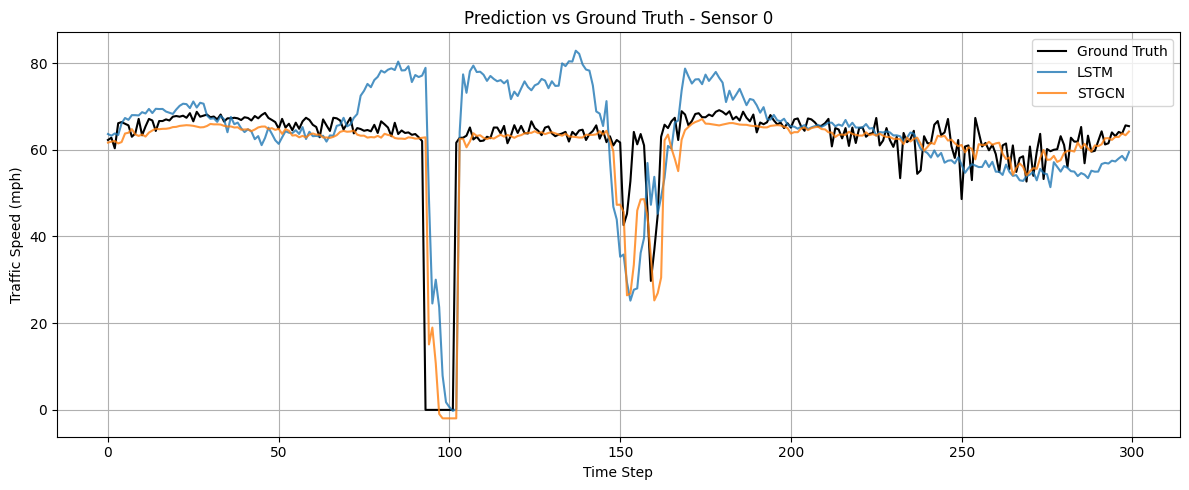

In [40]:
import matplotlib.pyplot as plt

sensor_idx = 0
num_points = 300

plt.figure(figsize=(12, 5))
plt.plot(lstm_targets_denorm[:num_points, sensor_idx], label="Ground Truth", color="black")
plt.plot(lstm_preds_denorm[:num_points, sensor_idx], label="LSTM", alpha=0.8)
plt.plot(stgcn_preds_denorm[:num_points, sensor_idx], label="STGCN", alpha=0.8)

plt.xlabel("Time Step")
plt.ylabel("Traffic Speed (mph)")
plt.title(f"Prediction vs Ground Truth - Sensor {sensor_idx}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

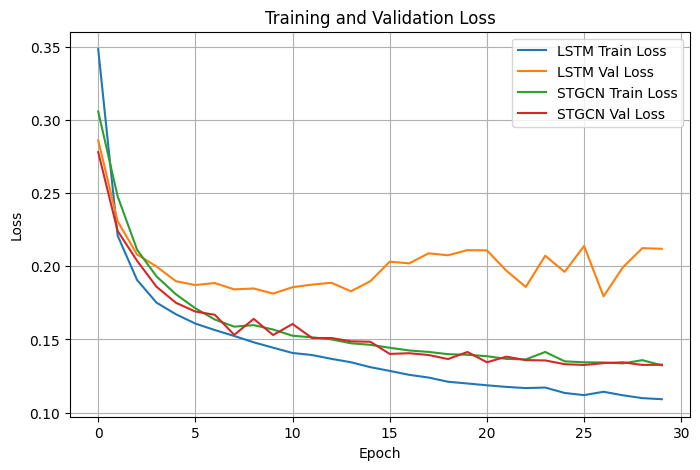

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(lstm_train_losses, label="LSTM Train Loss")
plt.plot(lstm_val_losses, label="LSTM Val Loss")
plt.plot(stgcn_train_losses, label="STGCN Train Loss")
plt.plot(stgcn_val_losses, label="STGCN Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", "/content/ECE1508Project.ipynb"])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', '/content/ECE1508Project.ipynb'], returncode=0)